# Customer Data Cleaning Project
## End-to-End Data Preprocessing Case Study

### Objective
Prepare a raw customer dataset for analytics by identifying and resolving common data quality issues including missing values, inconsistent formats, duplicates, and outliers.

### Skills Demonstrated
- Data Cleaning
- Pandas
- NumPy
- Seaborn
- Matplotlib
- SciPy
- Feature Preparation


# Workflow

1. Import Libraries
2. Load Dataset
3. Initial Data Inspection
4. Missing Value Analysis
5. Data Type Corrections
6. Standardize Text Values
7. Handle Missing Values
8. Remove Duplicates
9. Detect & Remove Outliers
10. Validate Cleaned Data
11. Final Summary


# Customer Data Cleaning Project

## Problem Statement
Clean a customer dataset by handling missing values, correcting data types, standardizing text values, removing duplicates, and detecting/removing outliers so the data is ready for analysis and machine learning.

## Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy


In [92]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
uploaded = files.upload()

Saving messy_customer_sales_data.csv to messy_customer_sales_data (1).csv


In [ ]:
df = pd.read_csv('messy_customer_sales_data.csv')
df_original = df.copy()
df.head()

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India


In [ ]:
df.shape

(10200, 12)

In [ ]:
df.describe().round()

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9177 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                9177 non-null   object 
 2   Gender              9177 non-null   object 
 3   Age                 9177 non-null   int64  
 4   City                9177 non-null   object 
 5   Signup_Date         9177 non-null   object 
 6   Last_Purchase_Date  9177 non-null   object 
 7   Purchase_Amount     9177 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               9177 non-null   object 
 10  Phone_Number        9177 non-null   int64  
 11  Country             9177 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 932.0+ KB


In [ ]:
df.isnull().sum()

,0
Customer_ID,1023
Name,0
Gender,1026
Age,951
City,1016
Signup_Date,0
Last_Purchase_Date,1012
Purchase_Amount,1021
Feedback_Score,1023
Email,0


In [ ]:
df.dropna(subset = ['Customer_ID'], inplace = True)

In [ ]:
df['Age']

,Age
0,52.0
1,51.0 years
2,62.0
3,40.0
4,41.0
...,...
10194,40.0
10195,35.0 years
10197,25.0
10198,55.0


In [114]:
def filter_age(age):
    if isinstance(age, str):
        return age.split()[0]
    return abs(age)

df['Age'] = df['Age'].apply(filter_age)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mode())

In [ ]:
df_age = df[df['Age'] != 'nan']['Age']

In [89]:
age_median = int(df_age.astype(float).median())

In [85]:
df['Age'] = df['Age'].replace('nan', age_median)
df['Age'] = df['Age'].fillna(age_median)

In [116]:
df['Age'].unique()

array([ 52,  51,  62,  40,  41,  43,  18,  26,  32,  22,  59,  65,  61,
        31,  54,  55,  69,  24,  63,  19,  50,  56,  36,  68,  38,  27,
        57,  23,  25,  66,  28,  30,  46,  48,  20,  37,  67,  35,  58,
        29,  39,  49,  47,  42,  44,  64,  53,  60,  45,  21,  34,  33,
       250,   3,  10])

In [ ]:
df['Last_Purchase_Date'] = df['Last_Purchase_Date'].ffill()

In [ ]:
df['Purchase_Amount'] = df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

In [79]:
for col in ['Gender', 'City', 'Country', 'Feedback_Score']:
  df[col] = df[col].fillna(df[col].mode()[0])

In [84]:
df.isnull().sum()

,0
Customer_ID,0
Name,0
Gender,0
Age,0
City,0
Signup_Date,0
Last_Purchase_Date,0
Purchase_Amount,0
Feedback_Score,0
Email,0


In [101]:
df['Gender'] = df['Gender'].str.strip().str.lower().replace({'m':'male', 'f':'female'})

In [103]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [104]:
df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [108]:
df['Country'] = df['Country'].str.lower().replace('ind', 'india')

In [109]:
df['Country'].unique()

array(['india'], dtype=object)

In [140]:
df.duplicated().sum()

np.int64(66)

In [141]:
df = df.drop_duplicates()

In [160]:
df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

In [163]:
df.describe().round()

,Age,Purchase_Amount,Feedback_Score,Phone_Number
count,9000.0,9000.0,9000.0,9.000000e+03
mean,44.0,29082.0,5.0,4.983041e+09
std,15.0,210705.0,3.0,2.901555e+09
min,3.0,-500.0,1.0,9.208990e+05
25%,32.0,13830.0,2.0,2.449808e+09
50%,43.0,24268.0,5.0,4.998591e+09
75%,55.0,35671.0,8.0,7.510124e+09
max,250.0,9999999.0,10.0,9.994402e+09


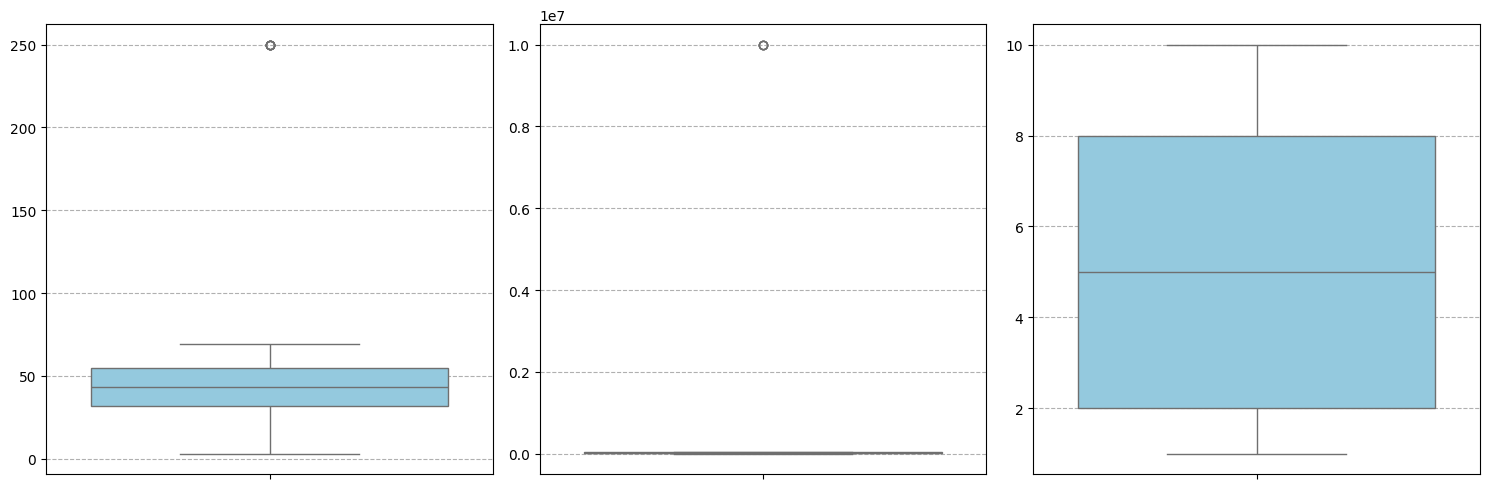

In [169]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(data = df, y = df[col], color = 'skyblue')
  plt.grid(linestyle = '--', axis = 'y')
  plt.ylabel('')
plt.tight_layout()
plt.show()


In [168]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[['Age', 'Purchase_Amount']]))
df_clean = df[~(z_scores > 3).any(axis = 1)]

In [166]:
df_clean.shape

(8989, 12)

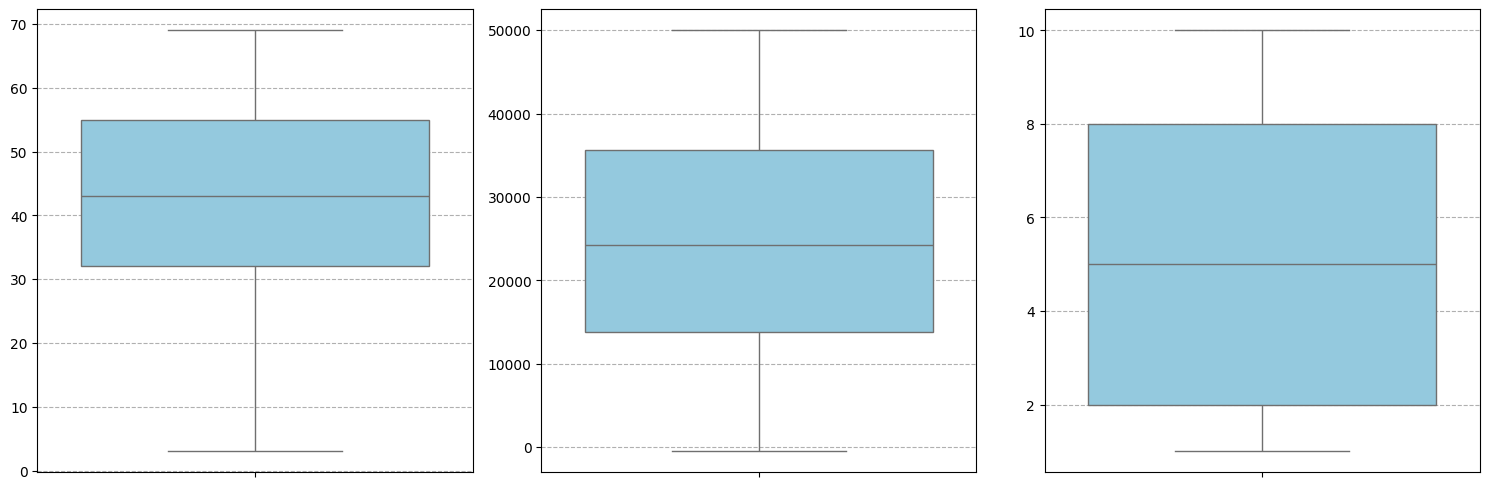

In [171]:
cols = ['Age', 'Purchase_Amount', 'Feedback_Score']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(data = df_clean, y = df_clean[col], color = 'skyblue')
  plt.grid(linestyle = '--', axis = 'y')
  plt.ylabel('')
plt.tight_layout()
plt.show()


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9000 non-null   object 
 1   Name                9000 non-null   object 
 2   Gender              9000 non-null   object 
 3   Age                 9000 non-null   int64  
 4   City                9000 non-null   object 
 5   Signup_Date         9000 non-null   object 
 6   Last_Purchase_Date  9000 non-null   object 
 7   Purchase_Amount     9000 non-null   float64
 8   Feedback_Score      9000 non-null   float64
 9   Email               9000 non-null   object 
 10  Phone_Number        9000 non-null   int64  
 11  Country             9000 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 914.1+ KB


In [173]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   object        
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 914.1+ KB


# Cleaning Decisions

- Removed rows with missing **Customer_ID** because it is a unique identifier.
- Converted columns to appropriate numeric/date data types.
- Filled numeric missing values using the **median**.
- Filled categorical missing values using the **mode**.
- Standardized inconsistent categorical values.
- Removed duplicate records.
- Detected and removed outliers using the **Z-score** method.


# Conclusion

The dataset has been cleaned by resolving missing values, correcting data types, standardizing categorical data, removing duplicates, and treating outliers. The resulting dataset is ready for Exploratory Data Analysis (EDA) and machine learning workflows.


## Why Each Cleaning Step?

### Missing Values
- Median was used for skewed numerical columns because it is robust to outliers.
- Mode was used for categorical columns because it preserves the most common category.

### Data Types
Columns were converted to appropriate numeric and datetime formats to enable analysis.

### Duplicates
Duplicate records were removed to avoid biased statistics.

### Outliers
Z-score (>3) was used to identify extreme observations in numerical features.


# Business Impact

Clean data improves:
- Reliability of dashboards
- Accuracy of statistical analysis
- Performance of machine learning models
- Confidence in business decisions


# Conclusion

This project demonstrates an end-to-end data cleaning workflow using Python and Pandas. The dataset was inspected, cleaned, standardized, validated, and prepared for downstream exploratory analysis and machine learning. The notebook follows reproducible preprocessing practices commonly used by data analysts and data scientists.
